In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

# Метрические методы регрессии

# Ядерная регрессия Надарая-Ватсона

In [2]:
def gaussian_kernel(r):
    return np.exp(-0.5 * r ** 2)


def epanechnikov_kernel(r):
    return np.where(np.abs(r) <= 1, 0.75 * (1 - r ** 2), 0.0)


def quartic_kernel(r):
    return np.where(np.abs(r) <= 1, (15 / 16) * (1 - r ** 2) ** 2, 0.0)


def triangular_kernel(r):
    return np.where(np.abs(r) <= 1, 1 - np.abs(r), 0.0)

In [3]:
KERNELS = {
    "gaussian": gaussian_kernel,
    "epanechnikov": epanechnikov_kernel,
    "quartic": quartic_kernel,
    "triangular": triangular_kernel,
}

In [4]:
class BaseNadarayaWatson:
    def __init__(self, kernel="gaussian"):
        self.kernel = kernel
        self.kernel_func = KERNELS[kernel]

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y, dtype=float)
        return self

    def _distances(self, X):
        diff = X[:, None, :] - self.X_train[None, :, :]
        return np.sqrt(np.sum(diff ** 2, axis=2))

    def _weight_matrix(self, X):
        raise NotImplementedError

    def _average(self, weights, gamma=None):
        if gamma is not None:
            weights = weights * gamma[None, :]
        denominator = weights.sum(axis=1)
        empty = denominator == 0
        if empty.any():
            warnings.warn(
                f"{empty.sum()} объектов без соседей в окне: вернётся NaN",
                RuntimeWarning,
            )
        numerator = weights @ self.y_train
        safe_denominator = np.where(empty, np.nan, denominator)
        return numerator / safe_denominator

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        weights = self._weight_matrix(X)
        return self._average(weights)

In [5]:
class NWFixed(BaseNadarayaWatson):
    def __init__(self, kernel="gaussian", h=1.0):
        super().__init__(kernel)
        self.h = h

    def _weight_matrix(self, X):
        dist = self._distances(X)
        return self.kernel_func(dist / self.h)


class NWVariable(BaseNadarayaWatson):
    def __init__(self, kernel="gaussian", k=5):
        super().__init__(kernel)
        self.k = k

    def _weight_matrix(self, X):
        dist = self._distances(X)
        h = np.sort(dist, axis=1)[:, self.k][:, None]
        return self.kernel_func(dist / h)

# Робастная регрессия LOWESS

In [6]:
class Lowess:
    def __init__(self, base_estimator, gamma_kernel="quartic",
                 n_iter=10, tol=1e-4):
        self.base_estimator = base_estimator
        self.gamma_kernel = KERNELS[gamma_kernel]
        self.n_iter = n_iter
        self.tol = tol

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.base_estimator.fit(X, y)

        weights = self.base_estimator._weight_matrix(X)
        np.fill_diagonal(weights, 0.0)

        n = len(y)
        gamma = np.ones(n)

        for _ in range(self.n_iter):
            w = weights * gamma[None, :]
            denom = w.sum(axis=1)
            denom = np.where(denom == 0, np.nan, denom)
            a = (w @ y) / denom

            eps = np.abs(a - y)
            scale = 6 * np.median(eps[~np.isnan(eps)])
            if scale == 0:
                break

            new_gamma = self.gamma_kernel(eps / scale)
            new_gamma = np.nan_to_num(new_gamma, nan=0.0)

            if np.max(np.abs(new_gamma - gamma)) < self.tol:
                gamma = new_gamma
                break
            gamma = new_gamma

        self.gamma_ = gamma
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        weights = self.base_estimator._weight_matrix(X)
        return self.base_estimator._average(weights, gamma=self.gamma_)

In [7]:
def loo_mse(estimator_class, X, y, kernel, param_name, param_value):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    estimator = estimator_class(kernel=kernel, **{param_name: param_value})
    estimator.fit(X, y)

    weights = estimator._weight_matrix(X)
    np.fill_diagonal(weights, 0.0)

    denom = weights.sum(axis=1)
    denom = np.where(denom == 0, np.nan, denom)
    preds = (weights @ y) / denom

    mask = ~np.isnan(preds)
    if mask.sum() == 0:
        return np.inf
    return np.mean((preds[mask] - y[mask]) ** 2)


def select_params(estimator_class, X, y, kernels, param_name, param_grid):
    results = {}
    best = (None, None, np.inf)
    for kernel in kernels:
        for value in param_grid:
            score = loo_mse(estimator_class, X, y, kernel, param_name, value)
            results[(kernel, value)] = score
            if score < best[2]:
                best = (kernel, value, score)
    return best, results

# y = sin x + eps

In [8]:
rng = np.random.default_rng(42)

In [9]:
n = 70
x = np.linspace(0, 4 * np.pi, n)
true_f = np.sin(x)
noise = rng.normal(0, 0.3, size=n)
y = true_f + noise

X = x[:, None]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=38
)

x_grid = np.linspace(0, 4 * np.pi, 500)[:, None]

In [10]:
model = NWFixed(kernel="gaussian", h=0.5)
model.fit(X_train, y_train)
pred_test = model.predict(X_test)

mse = np.mean((pred_test - y_test) ** 2)
print(f"MSE на тесте при h=0.5: {mse:.4f}")

MSE на тесте при h=0.5: 0.0913


In [11]:
h_grid = np.linspace(0.1, 3.0, 40)

best_fixed, results_fixed = select_params(
    NWFixed, X_train, y_train,
    kernels=["gaussian"], param_name="h", param_grid=h_grid
)

print(f"Лучшее h: {best_fixed[1]:.3f}, LOO-MSE: {best_fixed[2]:.4f}")

Лучшее h: 0.323, LOO-MSE: 0.0731


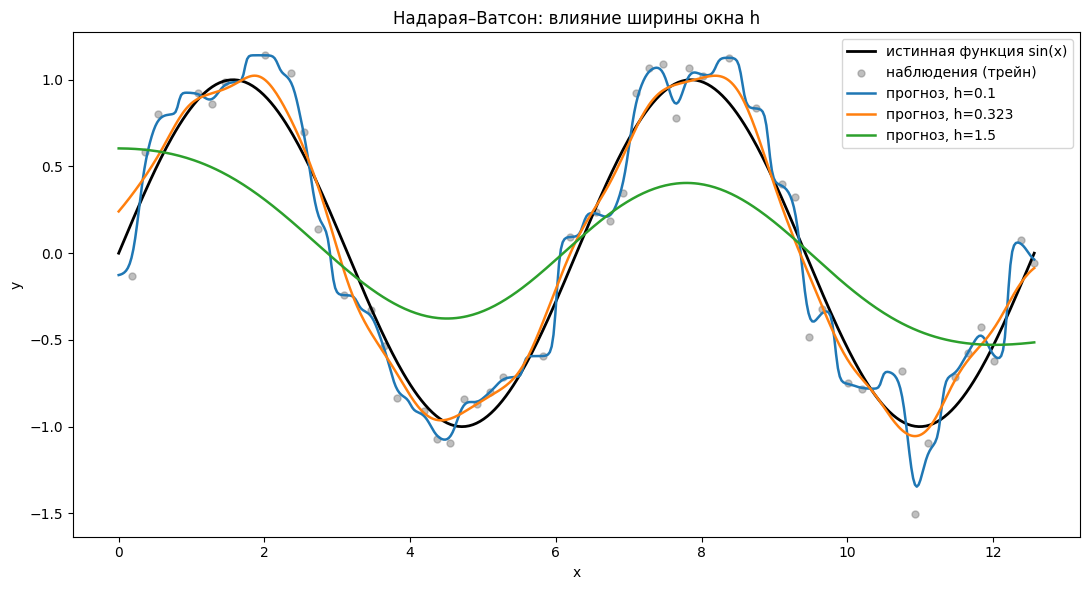

In [12]:
h_values = [0.1, 0.323, 1.5]

plt.figure(figsize=(11, 6))
plt.plot(x_grid[:, 0], np.sin(x_grid[:, 0]),
         color="black", lw=2, label="истинная функция sin(x)")
plt.scatter(X_train[:, 0], y_train, s=25, alpha=0.5,
            color="gray", label="наблюдения (трейн)")

for h in h_values:
    m = NWFixed(kernel="gaussian", h=h).fit(X_train, y_train)
    pred = m.predict(x_grid)
    plt.plot(x_grid[:, 0], pred, lw=1.8, label=f"прогноз, h={h}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Надарая–Ватсон: влияние ширины окна h")
plt.legend()
plt.tight_layout()
plt.savefig("h_curves.png", dpi=150, bbox_inches="tight")
plt.show()

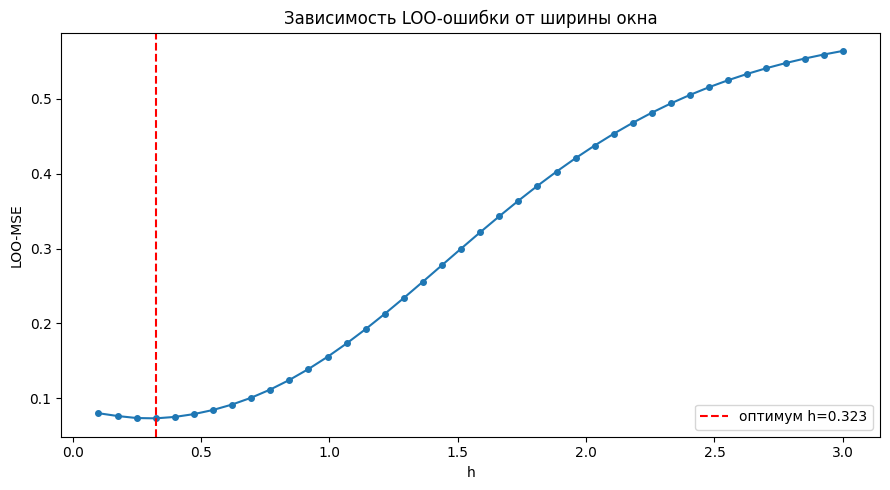

In [13]:
h_grid = np.linspace(0.1, 3.0, 40)
best_fixed, results_fixed = select_params(
    NWFixed, X_train, y_train,
    kernels=["gaussian"], param_name="h", param_grid=h_grid
)

hs = [k[1] for k in results_fixed]
errs = [results_fixed[k] for k in results_fixed]

plt.figure(figsize=(9, 5))
plt.plot(hs, errs, marker="o", ms=4)
plt.axvline(best_fixed[1], color="red", ls="--",
            label=f"оптимум h={best_fixed[1]:.3f}")
plt.xlabel("h")
plt.ylabel("LOO-MSE")
plt.title("Зависимость LOO-ошибки от ширины окна")
plt.legend()
plt.tight_layout()
plt.savefig("h_error.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
k_grid = np.arange(2, 40)

best_var, results_var = select_params(
    NWVariable, X_train, y_train,
    kernels=["quartic"], param_name="k", param_grid=k_grid
)

print(f"Лучшее k: {best_var[1]}, LOO-MSE: {best_var[2]:.4f}")

Лучшее k: 5, LOO-MSE: 0.0728


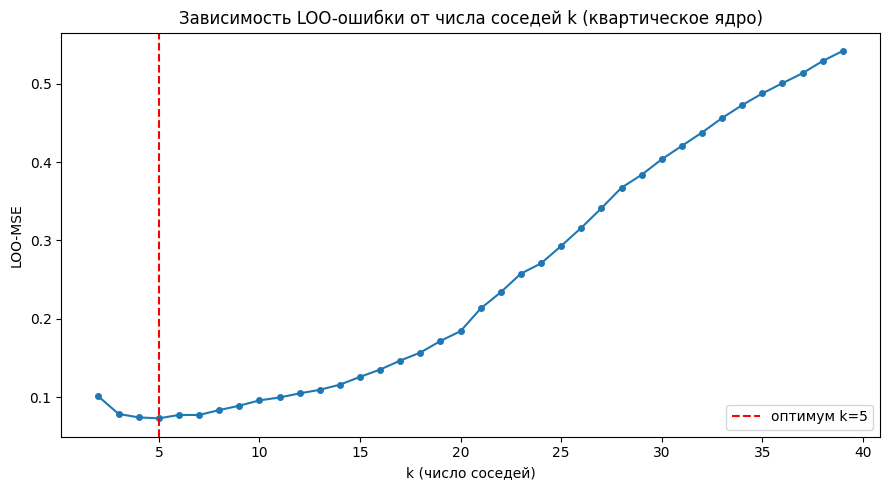

In [15]:
ks = [key[1] for key in results_var]
errs_var = [results_var[key] for key in results_var]

plt.figure(figsize=(9, 5))
plt.plot(ks, errs_var, marker="o", ms=4)
plt.axvline(best_var[1], color="red", ls="--",
            label=f"оптимум k={best_var[1]}")
plt.xlabel("k (число соседей)")
plt.ylabel("LOO-MSE")
plt.title("Зависимость LOO-ошибки от числа соседей k (квартическое ядро)")
plt.legend()
plt.tight_layout()
plt.savefig("k_error.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
h_grid = np.linspace(0.1, 3.0, 60)

best_per_kernel = {}
for kernel in KERNELS:
    best, results = select_params(
        NWFixed, X_train, y_train,
        kernels=[kernel], param_name="h", param_grid=h_grid
    )
    best_per_kernel[kernel] = best
    print(f"{kernel:14s} лучшее h={best[1]:.3f}, LOO-MSE={best[2]:.4f}")

gaussian       лучшее h=0.297, LOO-MSE=0.0730
epanechnikov   лучшее h=0.739, LOO-MSE=0.0737
quartic        лучшее h=0.837, LOO-MSE=0.0738
triangular     лучшее h=0.739, LOO-MSE=0.0728


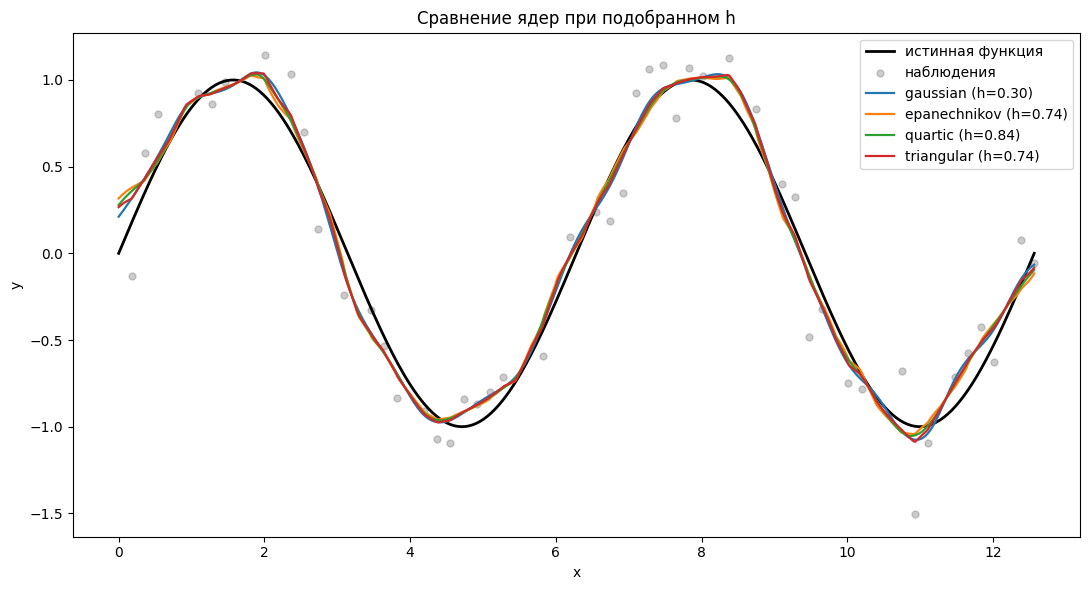

In [17]:
plt.figure(figsize=(11, 6))
plt.plot(x_grid[:, 0], np.sin(x_grid[:, 0]),
         color="black", lw=2, label="истинная функция")
plt.scatter(X_train[:, 0], y_train, s=25, alpha=0.4,
            color="gray", label="наблюдения")

for kernel in KERNELS:
    h_opt = best_per_kernel[kernel][1]
    m = NWFixed(kernel=kernel, h=h_opt).fit(X_train, y_train)
    pred = m.predict(x_grid)
    plt.plot(x_grid[:, 0], pred, lw=1.6,
             label=f"{kernel} (h={h_opt:.2f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Сравнение ядер при подобранном h")
plt.legend()
plt.tight_layout()
plt.savefig("kernels.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
for kernel in ["gaussian", "quartic", "epanechnikov"]:
    best_k, results_k = select_params(
        NWVariable, X_train, y_train,
        kernels=[kernel], param_name="k", param_grid=np.arange(2, 40)
    )
    model = NWVariable(kernel=kernel, k=best_k[1]).fit(X_train, y_train)
    mse_test = np.mean((model.predict(X_test) - y_test) ** 2)
    print(f"{kernel:13s} k={best_k[1]:2d}  LOO-MSE={best_k[2]:.4f}  "
          f"test-MSE={mse_test:.4f}")

gaussian      k= 2  LOO-MSE=0.0727  test-MSE=0.1015
quartic       k= 5  LOO-MSE=0.0728  test-MSE=0.1051
epanechnikov  k= 5  LOO-MSE=0.0740  test-MSE=0.1078


# Diabetes

In [19]:
data = load_diabetes()
X_dia, y_dia = data.data, data.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_dia, y_dia, test_size=0.3, random_state=38
)

scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

In [20]:
h_grid_dia = np.linspace(0.5, 8.0, 60)

best_fixed_dia, res_fixed_dia = select_params(
    NWFixed, X_tr, y_tr,
    kernels=["gaussian"], param_name="h", param_grid=h_grid_dia
)
print(f"Фиксированное окно: h={best_fixed_dia[1]:.3f}, LOO-MSE={best_fixed_dia[2]:.1f}")

k_grid_dia = np.arange(2, 60)

best_var_dia, res_var_dia = select_params(
    NWVariable, X_tr, y_tr,
    kernels=["quartic"], param_name="k", param_grid=k_grid_dia
)
print(f"Переменное окно: k={best_var_dia[1]}, LOO-MSE={best_var_dia[2]:.1f}")

Фиксированное окно: h=1.008, LOO-MSE=3487.3
Переменное окно: k=59, LOO-MSE=3482.9


In [21]:
def regression_metrics(y_true, y_pred):
    mask = ~np.isnan(y_pred)
    yt, yp = y_true[mask], y_pred[mask]
    mae = np.mean(np.abs(yt - yp))
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return mae, rmse, r2

In [22]:
nw_fix = NWFixed(kernel="gaussian", h=best_fixed_dia[1]).fit(X_tr, y_tr)
pred_fix = nw_fix.predict(X_te)

nw_var = NWVariable(kernel="quartic", k=best_var_dia[1]).fit(X_tr, y_tr)
pred_var = nw_var.predict(X_te)

print("Фиксированное окно:  MAE={:.1f}  RMSE={:.1f}  R2={:.3f}".format(
    *regression_metrics(y_te, pred_fix)))
print("Переменное окно: MAE={:.1f}  RMSE={:.1f}  R2={:.3f}".format(
    *regression_metrics(y_te, pred_var)))

Фиксированное окно:  MAE=43.1  RMSE=54.6  R2=0.447
Переменное окно: MAE=42.9  RMSE=54.2  R2=0.457


In [23]:
for kernel in ["gaussian", "quartic", "epanechnikov"]:
    best_k, _ = select_params(
        NWVariable, X_tr, y_tr,
        kernels=[kernel], param_name="k", param_grid=k_grid_dia
    )
    model = NWVariable(kernel=kernel, k=best_k[1]).fit(X_tr, y_tr)
    mae, rmse, r2 = regression_metrics(y_te, model.predict(X_te))
    print(f"{kernel:13s} k={best_k[1]:2d}  LOO-MSE={best_k[2]:6.1f}  "
          f"MAE={mae:.1f}  RMSE={rmse:.1f}  R2={r2:.3f}")

gaussian      k= 2  LOO-MSE=4055.2  MAE=49.3  RMSE=59.1  R2=0.352
quartic       k=59  LOO-MSE=3482.9  MAE=42.9  RMSE=54.2  R2=0.457
epanechnikov  k=32  LOO-MSE=3496.7  MAE=42.9  RMSE=54.1  R2=0.458


# California Housing

In [24]:
cal = fetch_california_housing()
X_cal_full, y_cal_full = cal.data, cal.target

idx = rng.choice(len(X_cal_full), size=3000, replace=False)
X_cal, y_cal = X_cal_full[idx], y_cal_full[idx]

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cal, y_cal, test_size=0.3, random_state=38
)

scaler_c = StandardScaler().fit(X_tr_c)
X_tr_c = scaler_c.transform(X_tr_c)
X_te_c = scaler_c.transform(X_te_c)

In [25]:
h_grid_cal = np.linspace(0.05, 4.0, 80)

best_fixed_cal, res_fixed_cal = select_params(
    NWFixed, X_tr_c, y_tr_c,
    kernels=["gaussian"], param_name="h", param_grid=h_grid_cal
)
print(f"Фиксированное окно: h={best_fixed_cal[1]:.3f}, LOO-MSE={best_fixed_cal[2]:.4f}")

k_grid_cal = np.arange(2, 60)

best_var_cal, res_var_cal = select_params(
    NWVariable, X_tr_c, y_tr_c,
    kernels=["quartic"], param_name="k", param_grid=k_grid_cal
)
print(f"Переменное окно: k={best_var_cal[1]}, LOO-MSE={best_var_cal[2]:.4f}")

Фиксированное окно: h=0.350, LOO-MSE=0.5081
Переменное окно: k=27, LOO-MSE=0.4839


In [26]:
nw_fix_c = NWFixed(kernel="gaussian", h=best_fixed_cal[1]).fit(X_tr_c, y_tr_c)
pred_fix_c = nw_fix_c.predict(X_te_c)

nw_var_c = NWVariable(kernel="quartic", k=best_var_cal[1]).fit(X_tr_c, y_tr_c)
pred_var_c = nw_var_c.predict(X_te_c)

print("Фиксированное окно:  MAE={:.3f}  RMSE={:.3f}  R2={:.3f}".format(
    *regression_metrics(y_te_c, pred_fix_c)))
print("Переменное окно: MAE={:.3f}  RMSE={:.3f}  R2={:.3f}".format(
    *regression_metrics(y_te_c, pred_var_c)))

Фиксированное окно:  MAE=0.535  RMSE=0.740  R2=0.619
Переменное окно: MAE=0.511  RMSE=0.722  R2=0.637


In [27]:
for kernel in ["gaussian", "quartic", "epanechnikov"]:
    best_k, _ = select_params(
        NWVariable, X_tr_c, y_tr_c,
        kernels=[kernel], param_name="k", param_grid=k_grid_cal
    )
    model = NWVariable(kernel=kernel, k=best_k[1]).fit(X_tr_c, y_tr_c)
    mae, rmse, r2 = regression_metrics(y_te_c, model.predict(X_te_c))
    print(f"{kernel:13s} k={best_k[1]:2d}  LOO-MSE={best_k[2]:.4f}  "
          f"MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

gaussian      k= 2  LOO-MSE=0.5713  MAE=0.602  RMSE=0.808  R2=0.546
quartic       k=27  LOO-MSE=0.4839  MAE=0.511  RMSE=0.722  R2=0.637
epanechnikov  k=20  LOO-MSE=0.4819  MAE=0.514  RMSE=0.724  R2=0.635


In [28]:
def make_data_with_outliers(n=80, noise=0.2, outlier_frac=0.15,
                            outlier_size=3.0, seed=0):
    gen = np.random.default_rng(seed)
    x = np.linspace(0, 4 * np.pi, n)
    true_f = np.sin(x)
    y = true_f + gen.normal(0, noise, size=n)

    n_out = int(n * outlier_frac)
    out_idx = gen.choice(n, size=n_out, replace=False)
    y[out_idx] += outlier_size

    is_outlier = np.zeros(n, dtype=bool)
    is_outlier[out_idx] = True
    return x[:, None], y, true_f, is_outlier

In [29]:
X_out, y_out, true_f, mask = make_data_with_outliers(seed=1)
print(f"Выбросов: {mask.sum()} из {len(y_out)}")

Выбросов: 12 из 80


In [30]:
h_grid_out = np.linspace(0.1, 2.0, 40)
best, _ = select_params(
    NWFixed, X_out, y_out,
    kernels=["gaussian"], param_name="h", param_grid=h_grid_out
)
h_opt = best[1]
print(f"Подобранное h: {h_opt:.3f}")

nw_plain = NWFixed(kernel="gaussian", h=h_opt).fit(X_out, y_out)
lowess = Lowess(NWFixed(kernel="gaussian", h=h_opt),
                gamma_kernel="quartic", n_iter=15).fit(X_out, y_out)

Подобранное h: 0.344


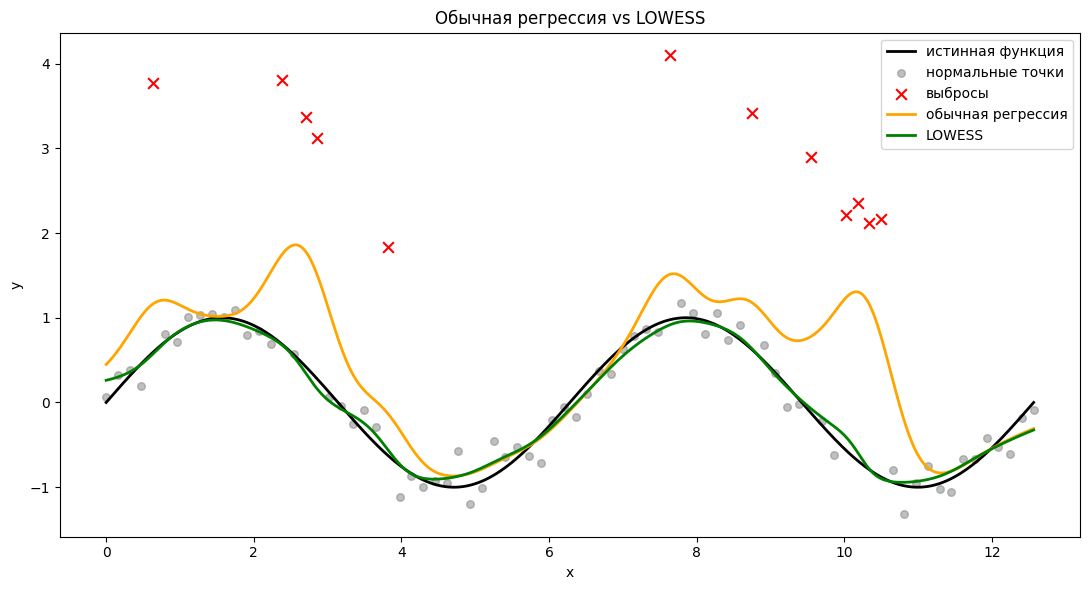

In [31]:
xg = np.linspace(0, 4 * np.pi, 500)[:, None]

plt.figure(figsize=(11, 6))
plt.plot(xg[:, 0], np.sin(xg[:, 0]), color="black", lw=2,
         label="истинная функция")
plt.scatter(X_out[~mask, 0], y_out[~mask], s=30, alpha=0.5,
            color="gray", label="нормальные точки")
plt.scatter(X_out[mask, 0], y_out[mask], s=60, color="red",
            marker="x", label="выбросы")
plt.plot(xg[:, 0], nw_plain.predict(xg), lw=2,
         color="orange", label="обычная регрессия")
plt.plot(xg[:, 0], lowess.predict(xg), lw=2,
         color="green", label="LOWESS")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Обычная регрессия vs LOWESS")
plt.legend()
plt.tight_layout()
plt.savefig("lowess_curves.png", dpi=150, bbox_inches="tight")
plt.show()

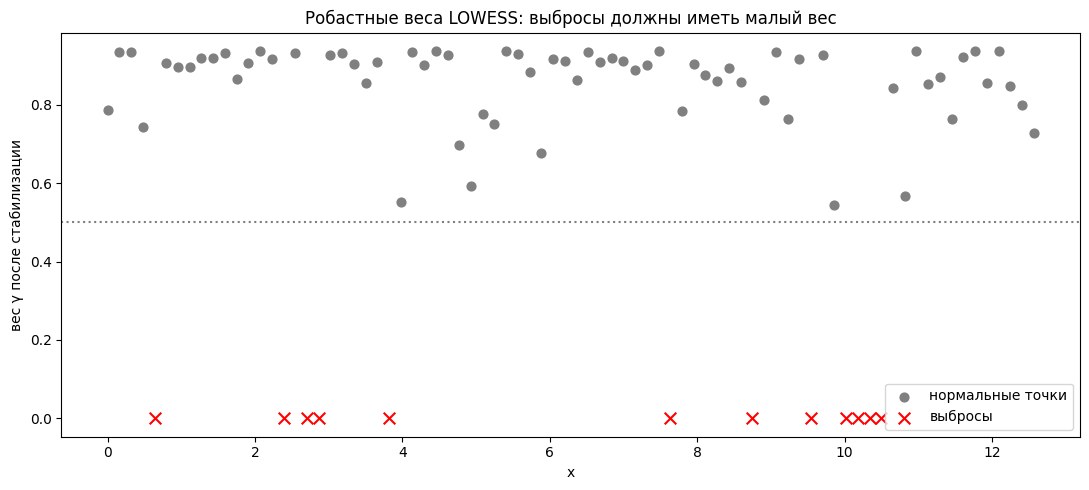

In [32]:
plt.figure(figsize=(11, 5))
plt.scatter(X_out[~mask, 0], lowess.gamma_[~mask], s=40,
            color="gray", label="нормальные точки")
plt.scatter(X_out[mask, 0], lowess.gamma_[mask], s=70,
            color="red", marker="x", label="выбросы")
plt.axhline(0.5, color="black", ls=":", alpha=0.5)
plt.xlabel("x")
plt.ylabel("вес γ после стабилизации")
plt.title("Робастные веса LOWESS: выбросы должны иметь малый вес")
plt.legend()
plt.tight_layout()
plt.savefig("gamma_weights.png", dpi=150, bbox_inches="tight")
plt.show()

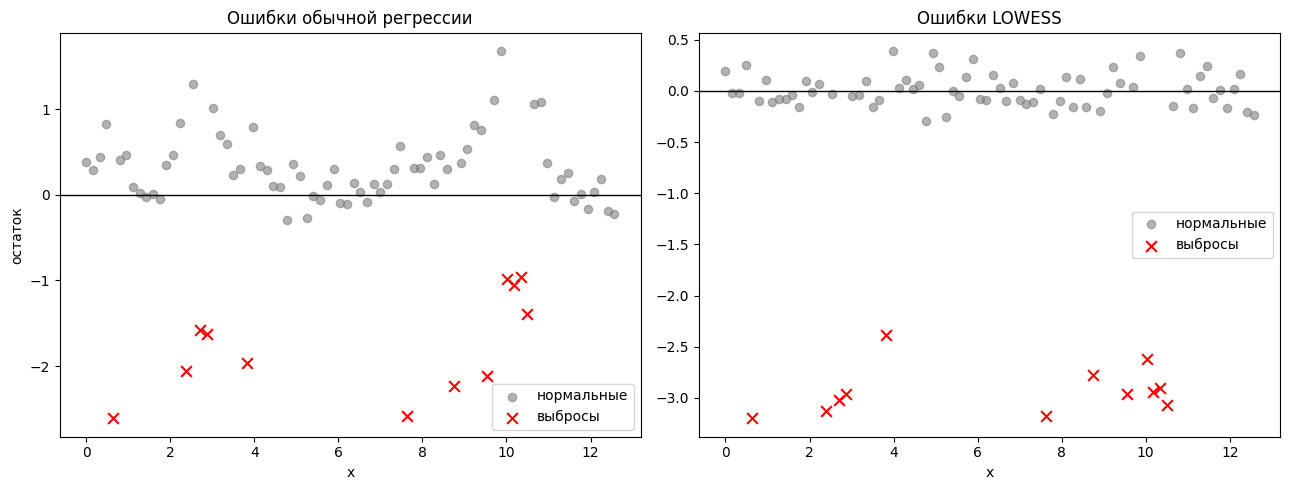

In [33]:
res_plain = nw_plain.predict(X_out) - y_out
res_lowess = lowess.predict(X_out) - y_out

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_out[~mask, 0], res_plain[~mask], s=35,
                color="gray", alpha=0.6, label="нормальные")
axes[0].scatter(X_out[mask, 0], res_plain[mask], s=60,
                color="red", marker="x", label="выбросы")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Ошибки обычной регрессии")
axes[0].set_xlabel("x")
axes[0].set_ylabel("остаток")
axes[0].legend()

axes[1].scatter(X_out[~mask, 0], res_lowess[~mask], s=35,
                color="gray", alpha=0.6, label="нормальные")
axes[1].scatter(X_out[mask, 0], res_lowess[mask], s=60,
                color="red", marker="x", label="выбросы")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Ошибки LOWESS")
axes[1].set_xlabel("x")
axes[1].legend()

plt.tight_layout()
plt.savefig("residuals.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
def split_mse(y_pred, y_true, mask):
    err = (y_pred - y_true) ** 2
    return err[~mask].mean(), err[mask].mean()

plain_norm, plain_out = split_mse(nw_plain.predict(X_out), y_out, mask)
low_norm, low_out = split_mse(lowess.predict(X_out), y_out, mask)

print("нормальные / выбросы")
print(f"Обычная регрессия {plain_norm:.3f} / {plain_out:.3f}")
print(f"LOWESS {low_norm:.3f} / {low_out:.3f}")

нормальные / выбросы
Обычная регрессия 0.251 / 3.423
LOWESS 0.026 / 8.630


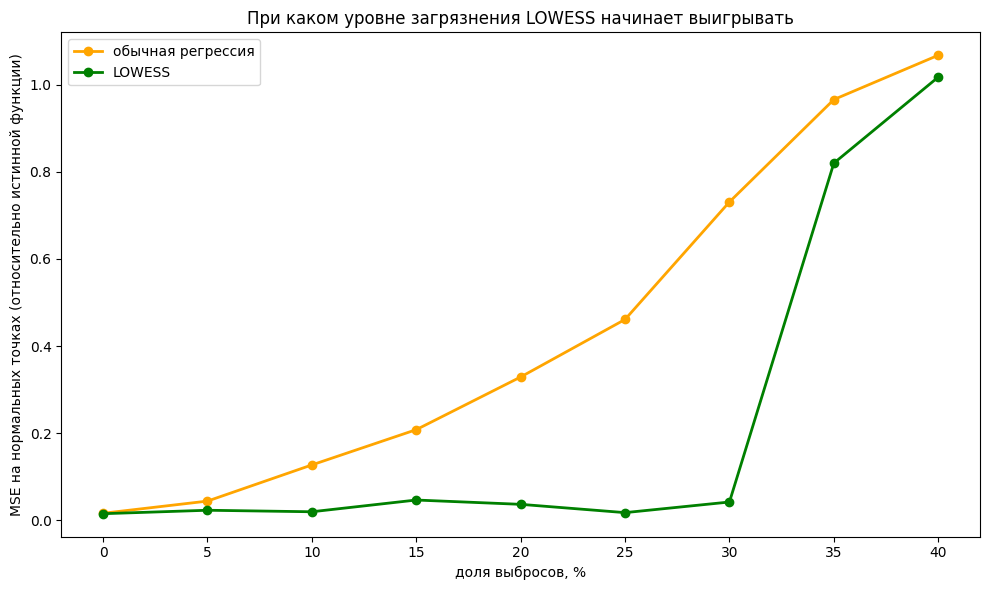

In [35]:
fracs = np.arange(0.0, 0.45, 0.05)
mse_plain_list = []
mse_lowess_list = []

for frac in fracs:
    X_c, y_c, true_c, mask_c = make_data_with_outliers(
        n=80, outlier_frac=frac, seed=10
    )

    best_c, _ = select_params(
        NWFixed, X_c, y_c,
        kernels=["gaussian"], param_name="h", param_grid=h_grid_out
    )
    h_c = best_c[1]

    plain = NWFixed(kernel="gaussian", h=h_c).fit(X_c, y_c)
    low = Lowess(NWFixed(kernel="gaussian", h=h_c),
                 gamma_kernel="quartic", n_iter=15).fit(X_c, y_c)

    clean = ~mask_c
    mse_plain_list.append(np.mean((plain.predict(X_c)[clean] - true_c[clean]) ** 2))
    mse_lowess_list.append(np.mean((low.predict(X_c)[clean] - true_c[clean]) ** 2))

plt.figure(figsize=(10, 6))
plt.plot(fracs * 100, mse_plain_list, marker="o", lw=2,
         color="orange", label="обычная регрессия")
plt.plot(fracs * 100, mse_lowess_list, marker="o", lw=2,
         color="green", label="LOWESS")
plt.xlabel("доля выбросов, %")
plt.ylabel("MSE на нормальных точках (относительно истинной функции)")
plt.title("При каком уровне загрязнения LOWESS начинает выигрывать")
plt.legend()
plt.tight_layout()
plt.savefig("contamination.png", dpi=150, bbox_inches="tight")
plt.show()